In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import json

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [2]:
df = pd.read_csv('../datasets/cleaned_yield.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (25932, 7)
Columns: ['country', 'crop', 'year', 'yield_hg_per_ha', 'rainfall_mm', 'pesticides_tonnes', 'avg_temp']


,country,crop,year,yield_hg_per_ha,rainfall_mm,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, Paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [3]:
print("Unique crops:", df['crop'].nunique())
print("Unique countries:", df['country'].nunique())
print("Year range:", df['year'].min(), "→", df['year'].max())
print("\nTarget column stats:")
print(df['yield_hg_per_ha'].describe())

Unique crops: 10
Unique countries: 101
Year range: 1990 → 2013

Target column stats:
count     25932.000000
mean      76978.132925
std       84647.605552
min          50.000000
25%       19996.000000
50%       39530.000000
75%      104168.000000
max      501412.000000
Name: yield_hg_per_ha, dtype: float64


In [4]:
# yield_hg_per_ha = hectograms per hectare
# 1 tonne = 10,000 hectograms
# So divide by 10,000 to get tonnes/hectare

df['yield_tonnes_per_ha'] = df['yield_hg_per_ha'] / 10000

print("Yield in tonnes/ha stats:")
print(df['yield_tonnes_per_ha'].describe())

Yield in tonnes/ha stats:
count    25932.000000
mean         7.697813
std          8.464761
min          0.005000
25%          1.999600
50%          3.953000
75%         10.416800
max         50.141200
Name: yield_tonnes_per_ha, dtype: float64


In [7]:
from sklearn.preprocessing import LabelEncoder
import pickle

# Re-encode here directly
le_yield_crop = LabelEncoder()
le_country = LabelEncoder()

df['crop_encoded'] = le_yield_crop.fit_transform(df['crop'])
df['country_encoded'] = le_country.fit_transform(df['country'])

# Save encoders (overwrite with correct ones)
pickle.dump(le_yield_crop, open('../models/yield_crop_encoder.pkl', 'wb'))
pickle.dump(le_country, open('../models/country_encoder.pkl', 'wb'))

print("✅ Encoders created and saved!")
print("Unique crops:", df['crop'].nunique())
print("Unique countries:", df['country'].nunique())
print("\nColumns now:", df.columns.tolist())

✅ Encoders created and saved!
Unique crops: 10
Unique countries: 101

Columns now: ['country', 'crop', 'year', 'yield_hg_per_ha', 'rainfall_mm', 'pesticides_tonnes', 'avg_temp', 'yield_tonnes_per_ha', 'crop_encoded', 'country_encoded']


In [8]:
X = df[['crop_encoded', 'country_encoded',
        'year', 'rainfall_mm',
        'pesticides_tonnes', 'avg_temp']]

y = df['yield_tonnes_per_ha']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Target range:", round(y.min(), 2), "→", round(y.max(), 2), "tonnes/ha")

Features shape: (25932, 6)
Target shape: (25932,)
Target range: 0.0 → 50.14 tonnes/ha


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 20745
Testing samples: 5187


In [11]:
models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    'XGBoost': XGBRegressor(
        n_estimators=100,
        random_state=42,
        verbosity=0
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    ),
    'Linear Regression': LinearRegression()
}

results = {}

print("Training models...\n")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R2': round(r2, 4)
    }
    print(f"✅ {name}")
    print(f"   MAE  : {mae:.4f} tonnes/ha")
    print(f"   RMSE : {rmse:.4f} tonnes/ha")
    print(f"   R²   : {r2:.4f}\n")

Training models...

✅ Random Forest
   MAE  : 0.4229 tonnes/ha
   RMSE : 1.1022 tonnes/ha
   R²   : 0.9832

✅ XGBoost
   MAE  : 0.8410 tonnes/ha
   RMSE : 1.5401 tonnes/ha
   R²   : 0.9673

✅ Gradient Boosting
   MAE  : 2.2745 tonnes/ha
   RMSE : 3.6744 tonnes/ha
   R²   : 0.8137

✅ Linear Regression
   MAE  : 6.2178 tonnes/ha
   RMSE : 8.1661 tonnes/ha
   R²   : 0.0799



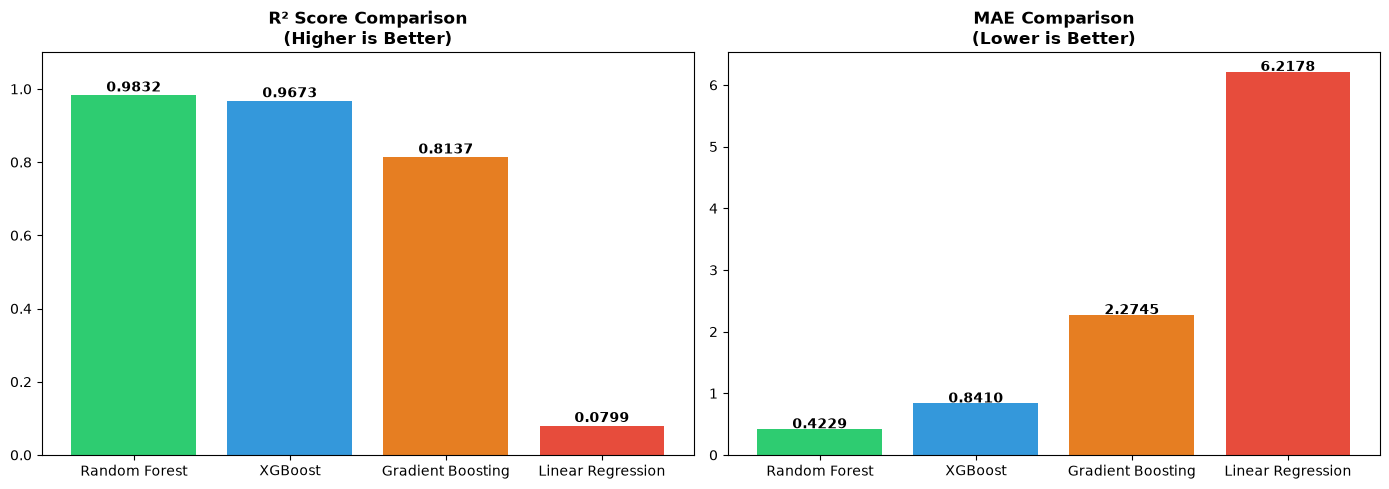

Chart saved!


In [12]:
names = list(results.keys())
r2_scores = [results[n]['R2'] for n in names]
mae_scores = [results[n]['MAE'] for n in names]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# R2 Score (higher is better)
colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']
bars1 = ax1.bar(names, r2_scores, color=colors)
ax1.set_title('R² Score Comparison\n(Higher is Better)',
              fontweight='bold')
ax1.set_ylim(0, 1.1)
for bar, v in zip(bars1, r2_scores):
    ax1.text(bar.get_x() + bar.get_width()/2,
             v + 0.01, f"{v:.4f}",
             ha='center', fontweight='bold')

# MAE (lower is better)
bars2 = ax2.bar(names, mae_scores, color=colors)
ax2.set_title('MAE Comparison\n(Lower is Better)',
              fontweight='bold')
for bar, v in zip(bars2, mae_scores):
    ax2.text(bar.get_x() + bar.get_width()/2,
             v + 0.01, f"{v:.4f}",
             ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../models/yield_model_comparison.png', dpi=150)
plt.show()
print("Chart saved!")

In [13]:
# Best = highest R2 score
best_name = max(results, key=lambda x: results[x]['R2'])
best_model = models[best_name]

print(f"🏆 Best Model: {best_name}")
print(f"   R²   : {results[best_name]['R2']}")
print(f"   MAE  : {results[best_name]['MAE']} tonnes/ha")
print(f"   RMSE : {results[best_name]['RMSE']} tonnes/ha")

🏆 Best Model: Random Forest
   R²   : 0.9832
   MAE  : 0.4229 tonnes/ha
   RMSE : 1.1022 tonnes/ha


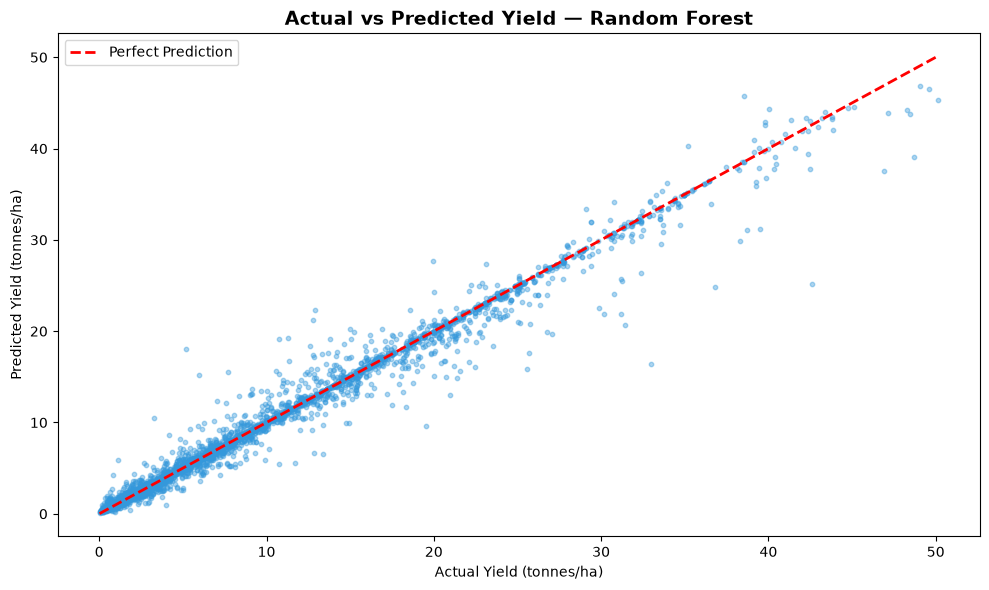

Plot saved!


In [14]:
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, alpha=0.4, color='#3498db', s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Yield (tonnes/ha)')
plt.ylabel('Predicted Yield (tonnes/ha)')
plt.title(f'Actual vs Predicted Yield — {best_name}',
          fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../models/yield_actual_vs_predicted.png', dpi=150)
plt.show()
print("Plot saved!")

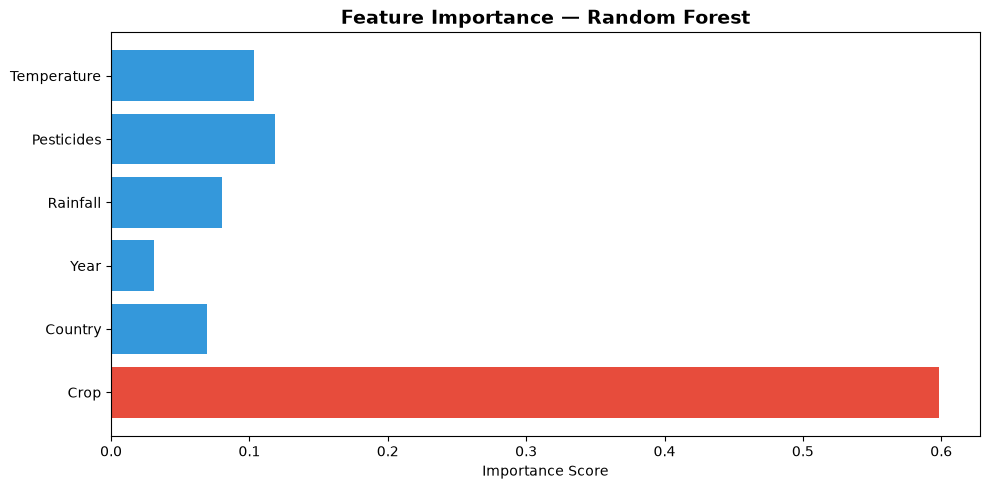

Feature importance saved!


In [15]:
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_names = ['Crop', 'Country', 'Year',
                     'Rainfall', 'Pesticides', 'Temperature']

    plt.figure(figsize=(10, 5))
    colors = ['#e74c3c' if x == max(importances) else '#3498db'
              for x in importances]
    plt.barh(feature_names, importances, color=colors)
    plt.title(f'Feature Importance — {best_name}',
              fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('../models/yield_feature_importance.png', dpi=150)
    plt.show()
    print("Feature importance saved!")

In [16]:
le_yield_crop = pickle.load(open('../models/yield_crop_encoder.pkl', 'rb'))
le_country = pickle.load(open('../models/country_encoder.pkl', 'rb'))

print("Sample crops available:")
print(list(le_yield_crop.classes_[:10]), "...")

print("\nSample countries available:")
print(list(le_country.classes_[:10]), "...")

Sample crops available:
['Cassava', 'Maize', 'Plantains And Others', 'Potatoes', 'Rice, Paddy', 'Sorghum', 'Soybeans', 'Sweet Potatoes', 'Wheat', 'Yams'] ...

Sample countries available:
['Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain'] ...


In [17]:
# Pick first available crop and country for testing
sample_crop = le_yield_crop.classes_[0]
sample_country = le_country.classes_[0]

crop_enc = le_yield_crop.transform([sample_crop])[0]
country_enc = le_country.transform([sample_country])[0]

sample = pd.DataFrame([[crop_enc, country_enc, 2024, 1200, 50, 25]],
                      columns=['crop_encoded', 'country_encoded',
                               'year', 'rainfall_mm',
                               'pesticides_tonnes', 'avg_temp'])

pred_yield = best_model.predict(sample)[0]

# Generate range (±10%)
low = round(pred_yield * 0.90, 2)
high = round(pred_yield * 1.10, 2)

print("📊 Yield Prediction Test")
print("-" * 35)
print(f"  Crop      : {sample_crop}")
print(f"  Country   : {sample_country}")
print(f"  Rainfall  : 1200 mm")
print(f"  Temp      : 25°C")
print(f"\n  ✅ Predicted Yield Range:")
print(f"     {low} — {high} tonnes/hectare")

📊 Yield Prediction Test
-----------------------------------
  Crop      : Cassava
  Country   : Albania
  Rainfall  : 1200 mm
  Temp      : 25°C

  ✅ Predicted Yield Range:
     16.37 — 20.0 tonnes/hectare


In [18]:
pickle.dump(best_model, open('../models/yield_model.pkl', 'wb'))
print(f"✅ Yield model saved: yield_model.pkl")
print(f"   Algorithm: {best_name}")
print(f"   R² Score : {results[best_name]['R2']}")

✅ Yield model saved: yield_model.pkl
   Algorithm: Random Forest
   R² Score : 0.9832


In [19]:
metadata = {
    'best_model': best_name,
    'r2_score': results[best_name]['R2'],
    'mae': results[best_name]['MAE'],
    'rmse': results[best_name]['RMSE'],
    'all_results': results,
    'features': ['crop_encoded', 'country_encoded', 'year',
                 'rainfall_mm', 'pesticides_tonnes', 'avg_temp'],
    'target': 'yield_tonnes_per_ha'
}

with open('../models/yield_model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print("✅ Metadata saved!")
print(json.dumps(metadata, indent=4))

✅ Metadata saved!
{
    "best_model": "Random Forest",
    "r2_score": 0.9832,
    "mae": 0.4229,
    "rmse": 1.1022,
    "all_results": {
        "Random Forest": {
            "MAE": 0.4229,
            "RMSE": 1.1022,
            "R2": 0.9832
        },
        "XGBoost": {
            "MAE": 0.841,
            "RMSE": 1.5401,
            "R2": 0.9673
        },
        "Gradient Boosting": {
            "MAE": 2.2745,
            "RMSE": 3.6744,
            "R2": 0.8137
        },
        "Linear Regression": {
            "MAE": 6.2178,
            "RMSE": 8.1661,
            "R2": 0.0799
        }
    },
    "features": [
        "crop_encoded",
        "country_encoded",
        "year",
        "rainfall_mm",
        "pesticides_tonnes",
        "avg_temp"
    ],
    "target": "yield_tonnes_per_ha"
}


In [20]:
print("=" * 40)
print("   PHASE 3 — YIELD MODEL COMPLETE")
print("=" * 40)

loaded = pickle.load(open('../models/yield_model.pkl', 'rb'))
test_pred = loaded.predict(sample)[0]

print(f"\n✅ Model loads correctly")
print(f"✅ Algorithm: {best_name}")
print(f"✅ R² Score: {results[best_name]['R2']}")
print(f"✅ Test prediction: {round(test_pred, 2)} tonnes/ha")
print("\nFiles saved in models/:")
print("  - yield_model.pkl")
print("  - yield_model_metadata.json")
print("  - yield_model_comparison.png")
print("  - yield_actual_vs_predicted.png")
print("  - yield_feature_importance.png")

   PHASE 3 — YIELD MODEL COMPLETE

✅ Model loads correctly
✅ Algorithm: Random Forest
✅ R² Score: 0.9832
✅ Test prediction: 18.18 tonnes/ha

Files saved in models/:
  - yield_model.pkl
  - yield_model_metadata.json
  - yield_model_comparison.png
  - yield_actual_vs_predicted.png
  - yield_feature_importance.png
